# Differential expression on pseudobulk with replicates

In [1]:
here::i_am("rna/mapping/run/mnn/mapping_mnn.R")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

# Load packages
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(org.Mm.eg.db))


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [2]:
args = list()
args$sce = file.path(io$basedir, 'results/rna/pseudobulk/celltype_genotype/SingleCellExperiment_pseudobulk_with_replicates.rds')
args$groupA = 'wt'
args$groupB = 'eomes_ko'
args$celltypes = opts$celltypes
args$outdir = file.path(io$basedir, 'results/rna/differential')

In [3]:
meta = fread(file.path(io$basedir, 'processed/rna/metadata.txt.gz'))

In [4]:

dir.create(args$outdir, showWarnings = F)

# Define groups
opts$groups <- c(args$groupA,args$groupB)

In [5]:
sce = readRDS(args$sce)

In [6]:
# parse annotations
if (!"celltype" %in% colnames(colData(sce))) {
  sce$celltype <- colnames(sce) %>% strsplit("-") %>% map_chr(1)
}
if (!"genotype" %in% colnames(colData(sce))) {
  sce$genotype <- colnames(sce) %>% strsplit("-") %>% map_chr(2) %>% strsplit("_rep") %>% map_chr(1)
}
if (!"celltype_genotype" %in% colnames(colData(sce))) {
  sce$celltype_genotype <- sprintf("%s_%s",sce$celltype,sce$genotype)
}

In [7]:
sce_full = sce

In [8]:
DEGs = lapply(args$celltypes, function(ct){
    print(ct)
    tmp <- sprintf("%s_%s",ct,opts$groups)
    if (any(!tmp%in%unique(sce_full$celltype_genotype))) {
      warning("...")
      out <- data.table(gene=NA, logFC=NA, padj_fdr=NA, mean_groupA=NA, mean_groupB=NA)
      #fwrite(out, args$outfile, sep="\t", na="NA", quote=F)
    } else {
      sce <- sce_full[,sce_full$celltype %in% ct]
    

        # subset genotypes
        stopifnot(opts$groups%in%sce$genotype)
        sce$genotype <- factor(sce$genotype, levels=opts$groups)
        print(table(sce$celltype_genotype))

        #########################################
        ## Calculate average expression levels ##
        #########################################

        expr.dt <- data.table(
          gene = rownames(sce),
          mean_groupA = rowMeans(logcounts(sce[,sce$genotype==args$groupA])) %>% round(2),
          mean_groupB = rowMeans(logcounts(sce[,sce$genotype==args$groupB])) %>% round(2)
        )

        #######################
        ## Feature selection ##
        #######################

        opts$min.expr <- 4 # 2**4 = 16, at least an average of 8 counts per milion for each group

        genes.to.use <- expr.dt[mean_groupA>=opts$min.expr | mean_groupB>=opts$min.expr,gene]

        ################################################
        ## Differential expression testing with edgeR ##
        ################################################

        # Convert SCE to DGEList
        sce_edger <- scran::convertTo(sce[genes.to.use,], type="edgeR")

        # Define design matrix (with intercept)
        design <- model.matrix(~sce$genotype)

        # Estimate dispersions
        sce_edger  <- estimateDisp(sce_edger,design)

        # Fit GLM
        fit <- glmQLFit(sce_edger,design)

        # Likelihood ratio test
        lrt <- glmQLFTest(fit)

        # Construct output data.frame
        out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
          setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
          .[,c("logCPM","LR","p.value"):=NULL] %>%
          .[,c("padj_fdr","logFC"):=list(signif(padj_fdr,digits=3), round(logFC,3))] %>%
          merge(expr.dt, by="gene", all.y=TRUE) %>%
          setorder(padj_fdr, na.last=T)
    }
    out = out %>% .[,celltype:=ct]
    return(out)
})

[1] "Epiblast"


Warning message in FUN(X[[i]], ...):
“...”


[1] "Primitive_Streak"

Primitive_Streak_eomes_ko       Primitive_Streak_wt 
                        5                         5 
[1] "Caudal_epiblast"


Warning message in FUN(X[[i]], ...):
“...”


[1] "PGC"

PGC_eomes_ko       PGC_wt 
           5            5 
[1] "Anterior_Primitive_Streak"

Anterior_Primitive_Streak_eomes_ko       Anterior_Primitive_Streak_wt 
                                 5                                  5 
[1] "Notochord"


...

Warning message in FUN(X[[i]], ...):
“...”


[1] "ExE_ectoderm"


Warning message in FUN(X[[i]], ...):
“...”


[1] "Parietal_endoderm"


Warning message in FUN(X[[i]], ...):
“...”


In [9]:
DEGs = rbindlist(DEGs)

In [10]:
fwrite(DEGs, file.path(args$outdir, 'DEGs.txt.gz'))

In [9]:
head(DEGs)

gene,logFC,padj_fdr,mean_groupA,mean_groupB,celltype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
NA,NA,NA,NA,NA,Epiblast
Hspd1,-0.700,1.06e-28,10.87,10.16,Primitive_Streak
Fat3,-2.694,4.60e-27,8.29,5.60,Primitive_Streak
Rplp1,0.507,4.60e-27,10.41,10.91,Primitive_Streak
Rps3,0.477,4.60e-27,10.42,10.89,Primitive_Streak
Aldoa,1.199,6.70e-27,7.70,8.89,Primitive_Streak


In [46]:
plot_DEGs = function(ct, nlabels=10){
    DEG_tmp = DEGs[celltype==ct & !is.na(logFC),] %>%
        .[, sig:=ifelse(abs(logFC)>1.5 & padj_fdr<0.05, TRUE, FALSE)]
   
    if(nrow(DEG_tmp)>1){
    labels_up = DEG_tmp[sig==TRUE & logFC>0,] %>% .[order(-logFC),] %>% head(nlabels)
    labels_down = DEG_tmp[sig==TRUE & logFC<0,] %>% .[order(logFC),] %>% head(nlabels)
    labels = rbind(labels_up, labels_down)
    
    xlim = max(abs(DEG_tmp$logFC))
    
    text = data.frame(dir=c('Up', 'Down'), 
                  gene=c(nrow(DEG_tmp[sig==TRUE & logFC>0,]), 
                          nrow(DEG_tmp[sig==TRUE & logFC<0,])),
                  logFC = c(xlim, -xlim), 
                  padj_fdr = min(DEG_tmp$padj_fdr),
                     sig=c('FALSE', 'FALSE'))
    
    DEG_plot = ggplot(DEG_tmp, aes(logFC, -log10(padj_fdr), col=sig, label=gene)) + 
        geom_point() + 
        geom_text(data=text, aes(logFC, -log10(padj_fdr), label=gene), size=8) + 
        xlim(-xlim, xlim) + 
        scale_color_manual(values=c('TRUE'='red', 'FALSE'='black')) + 
        geom_vline(xintercept = 0, col='red', linetype='dotted') +
        ggrepel::geom_text_repel(data=labels, 
                                 col='black', 
                                 max.overlaps=Inf,
                                 box.padding = 0.5) + 
        ggtitle(paste0(ct, ' - ', nrow(DEG_tmp), ' genes')) +
        theme_bw() + 
        theme(#text=element_text(size=15),
             legend.position='none')
    return(DEG_plot)

    }
}

plot_GO = function(ct, nlabels=10){
    DEG_tmp = DEGs[celltype==ct & !is.na(logFC),] %>%
        .[, sig:=ifelse(abs(logFC)>1.5 & padj_fdr<0.05, TRUE, FALSE)]
   
    if(nrow(DEG_tmp)>1){
    labels_up = DEG_tmp[sig==TRUE & logFC>0,] %>% .[order(-logFC),] %>% .$gene
    up_entrez = mapIds(org.Mm.eg.db, labels_up, 'ENTREZID', 'SYMBOL')
    up_GO = as.data.table(goana(up_entrez, species="Mm"), 
                          keep.rownames=T)[order(P.DE),] %>% .[Ont=='MF'] %>% head(nlabels) %>%
        .[,Term:=factor(Term, levels=Term)] %>%
        .[,direction:='up']
        
    labels_down = DEG_tmp[sig==TRUE & logFC<0,] %>% .[order(logFC),] %>% .$gene
    entrez = mapIds(org.Mm.eg.db, labels_down, 'ENTREZID', 'SYMBOL')
    down_entrez = entrez
    down_GO = as.data.table(goana(down_entrez, species="Mm"), 
                      keep.rownames=T)[order(P.DE),] %>% .[Ont=='MF'] %>% head(nlabels) %>%
        .[,Term:=factor(Term, levels=Term)] %>% 
        .[,direction:='down']
        
    GO_terms.plot = rbind(up_GO, down_GO)
    GO_terms.plot$Term = make.names(GO_terms.plot$Term, unique=TRUE)
    GO_terms.plot = GO_terms.plot[order(-P.DE),][,Term:=factor(Term, levels=Term)]

    GO_plot = ggplot(GO_terms.plot, aes(Term, -log10(P.DE), fill=direction)) +
        geom_bar(stat='identity', col='black') + 
        geom_point(y=0, size=8) + 
        coord_flip() + 
        geom_text(label=GO_terms.plot$DE, aes(y=0), col='white', fontface='bold', size=5) + 
        ggtitle('') +
        theme_bw() + 
        facet_wrap(~direction, scales='free', ncol=1) + 
        theme(text=element_text(size=15),
             legend.position='none',
             axis.title.y=element_blank(),
             axis.text.y=element_text(color='black'),
             axis.title.x=element_blank(),
             strip.background = element_rect(fill='white'))
    return(GO_plot)
    }
}

In [26]:
celltypes_keep = unique(DEGs[!is.na(gene),celltype])

In [12]:
DEG_plots = lapply(args$celltypes, plot_DEGs)
names(DEG_plots) = args$celltypes

DEG_plots_filt = list()
for(i in celltypes_keep){
DEG_plots_filt[[i]] = DEG_plots[[i]]
}

In [47]:
GO_plots = lapply(args$celltypes, plot_GO, nlabels=10)
names(GO_plots) = args$celltypes

GO_plots_filt = list()
for(i in celltypes_keep){
GO_plots_filt[[i]] = GO_plots[[i]]
}

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' ret

In [48]:
options(repr.plot.width=15, repr.plot.height=8) 
pdf(file.path(args$outdir, 'DEGs.pdf'), height=7, width=15)
for(i in celltypes_keep){
    print(ggarrange(DEG_plots_filt[[i]], GO_plots_filt[[i]]))
}
dev.off()

png 
  2

In [30]:
ct = 'Mixed_mesoderm'
nlabels=10

    DEG_tmp = DEGs[celltype==ct & !is.na(logFC),] %>%
        .[, sig:=ifelse(abs(logFC)>1.5 & padj_fdr<0.05, TRUE, FALSE)]
   
    if(nrow(DEG_tmp)>1){
    labels_up = DEG_tmp[sig==TRUE & logFC>0,] %>% .[order(-logFC),] %>% .$gene
    up_entrez = mapIds(org.Mm.eg.db, labels_up, 'ENTREZID', 'SYMBOL')
    up_GO = as.data.table(goana(up_entrez, species="Mm"), 
                          keep.rownames=T)[order(P.DE),] %>% .[Ont=='MF'] %>% head(nlabels) %>%
        .[,Term:=factor(Term, levels=Term)] %>%
        .[,direction:='up']
        
    labels_down = DEG_tmp[sig==TRUE & logFC<0,] %>% .[order(logFC),] %>% .$gene
    entrez = mapIds(org.Mm.eg.db, labels_down, 'ENTREZID', 'SYMBOL')
    down_entrez = entrez
    down_GO = as.data.table(goana(down_entrez, species="Mm"), 
                      keep.rownames=T)[order(P.DE),] %>% .[Ont=='MF'] %>% head(nlabels) %>%
        .[,Term:=factor(Term, levels=Term)] %>% 
        .[,direction:='down']
        
    GO_terms.plot = rbind(up_GO, down_GO)
    GO_terms.plot$Term = make.names(GO_terms.plot$Term, unique=TRUE)
    }

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



In [44]:
down_GO

rn,Term,Ont,N,DE,P.DE,direction
<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
GO:0005488,binding,MF,14025,32,5.593184e-07,down
GO:0046872,metal ion binding,MF,3576,15,9.517080e-06,down
GO:0043169,cation binding,MF,3674,15,1.325666e-05,down
GO:0038085,vascular endothelial growth factor binding,MF,6,2,2.209497e-05,down
GO:0005021,vascular endothelial growth factor-activated receptor activity,MF,7,2,3.090893e-05,down
GO:0004714,transmembrane receptor protein tyrosine kinase activity,MF,59,3,5.339756e-05,down
GO:0043167,ion binding,MF,5293,17,6.482028e-05,down
GO:0045296,cadherin binding,MF,69,3,8.533277e-05,down
GO:0017154,semaphorin receptor activity,MF,12,2,9.676563e-05,down


In [42]:
GO_terms.plot

rn,Term,Ont,N,DE,P.DE,direction
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
GO:0048018,receptor.ligand.activity,MF,498,4,1.161561e-04,up
GO:0030546,signaling.receptor.activator.activity,MF,506,4,1.235068e-04,up
GO:0030545,signaling.receptor.regulator.activity,MF,550,4,1.701362e-04,up
GO:0005125,cytokine.activity,MF,228,3,2.249546e-04,up
GO:0050785,advanced.glycation.end.product.receptor.activity,MF,1,1,5.328893e-04,up
GO:0051978,lysophospholipid.sodium.symporter.activity,MF,1,1,5.328893e-04,up
GO:0140348,lysophosphatidylcholine.flippase.activity,MF,1,1,5.328893e-04,up
GO:1901480,oleate.transmembrane.transporter.activity,MF,2,1,1.065512e-03,up
GO:0004666,prostaglandin.endoperoxide.synthase.activity,MF,2,1,1.065512e-03,up


In [40]:
head(up_GO)

rn,Term,Ont,N,DE,P.DE,direction
<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
GO:0048018,receptor ligand activity,MF,498,4,0.0001161561,up
GO:0030546,signaling receptor activator activity,MF,506,4,0.0001235068,up
GO:0030545,signaling receptor regulator activity,MF,550,4,0.0001701362,up
GO:0005125,cytokine activity,MF,228,3,0.0002249546,up
GO:0050785,advanced glycation end-product receptor activity,MF,1,1,0.0005328893,up
GO:0051978,lysophospholipid:sodium symporter activity,MF,1,1,0.0005328893,up


In [36]:
labels_up

[1] "Lefty1" "Ccno"   "Mfsd2a" "Zfp462" "Wnt3a"  "Krt19"  "Crlf1"  "Scn9a" 
 [9] "Psmb8"  "Ptgs1"  "Fmn1"   "Sgcd"   "Msgn1"  "Lgals3" "Tapbpl" "Acnat1"

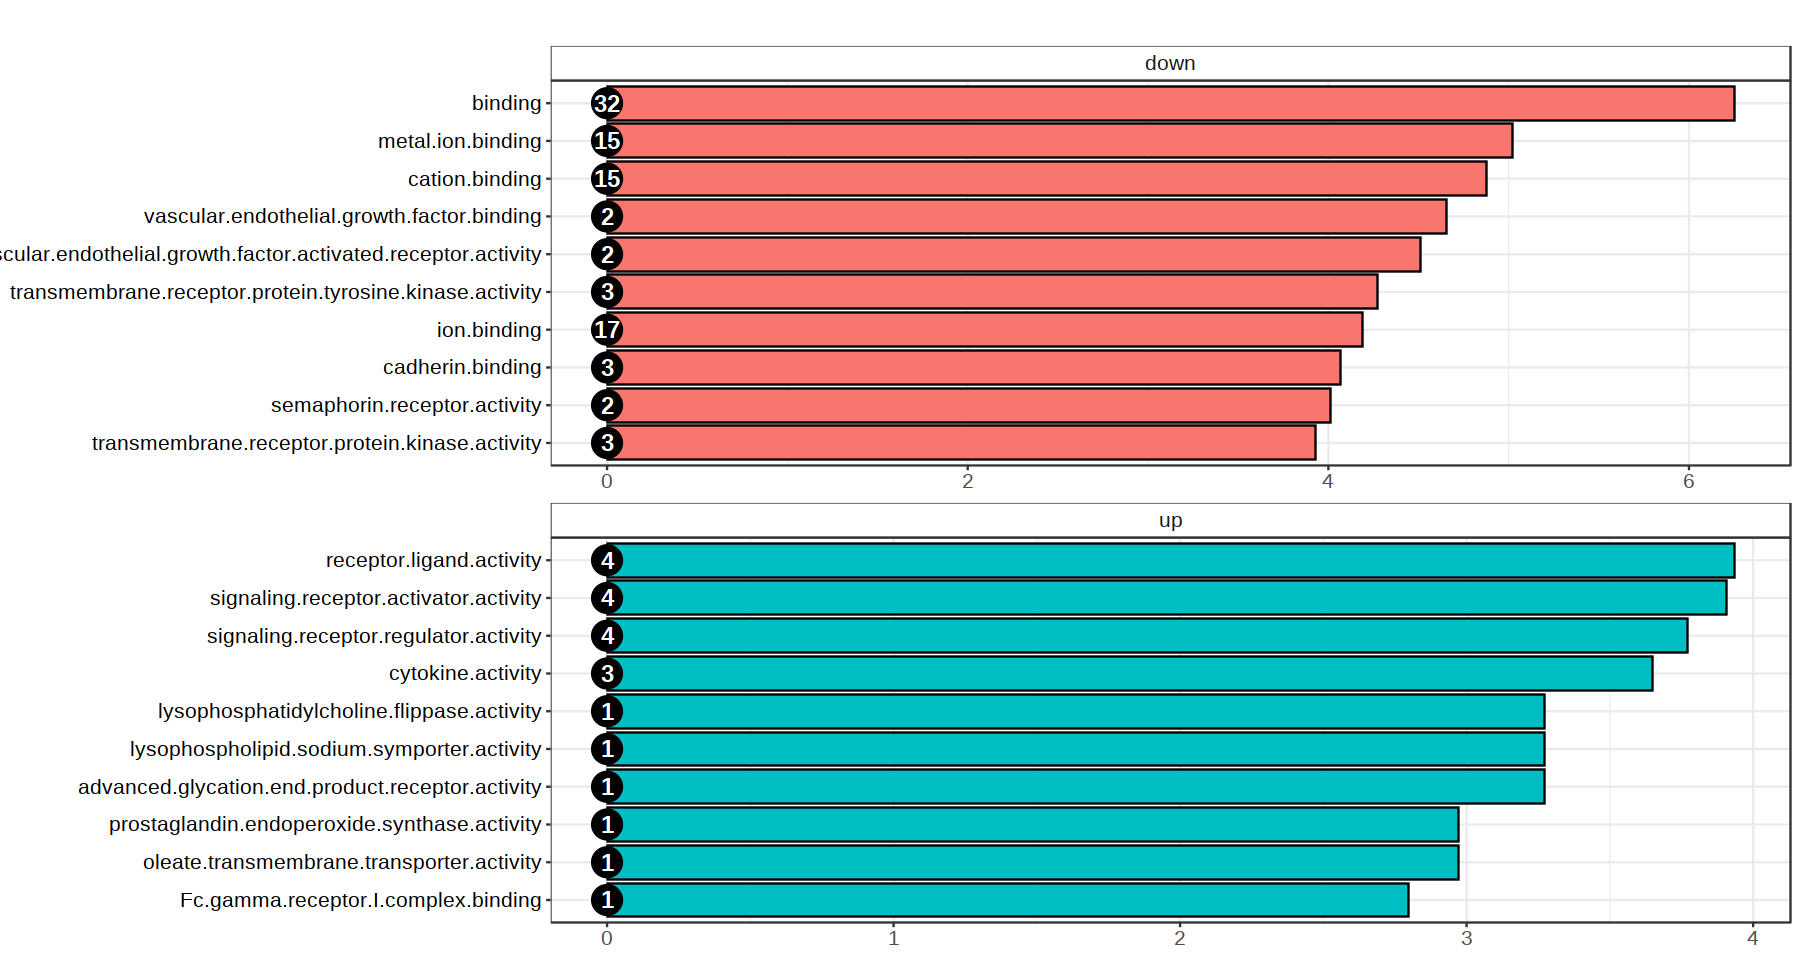

In [45]:
GO_terms.plot = GO_terms.plot[order(-P.DE),][,Term:=factor(Term, levels=Term)]
GO_plot = ggplot(GO_terms.plot, aes(Term, -log10(P.DE), fill=direction)) +
        geom_bar(stat='identity', col='black') + 
        geom_point(y=0, size=8) + 
        coord_flip() + 
        geom_text(label=GO_terms.plot$DE, aes(y=0), col='white', fontface='bold', size=5) + 
        ggtitle('') +
        theme_bw() + 
        facet_wrap(~direction, scales='free', ncol=1) + 
        theme(text=element_text(size=15),
             legend.position='none',
             axis.title.y=element_blank(),
             axis.text.y=element_text(color='black'),
             axis.title.x=element_blank(),
             strip.background = element_rect(fill='white'))
GO_plot

In [31]:
GO_terms.plot

rn,Term,Ont,N,DE,P.DE,direction
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
GO:0048018,receptor.ligand.activity,MF,498,4,1.161561e-04,up
GO:0030546,signaling.receptor.activator.activity,MF,506,4,1.235068e-04,up
GO:0030545,signaling.receptor.regulator.activity,MF,550,4,1.701362e-04,up
GO:0005125,cytokine.activity,MF,228,3,2.249546e-04,up
GO:0050785,advanced.glycation.end.product.receptor.activity,MF,1,1,5.328893e-04,up
GO:0051978,lysophospholipid.sodium.symporter.activity,MF,1,1,5.328893e-04,up
GO:0140348,lysophosphatidylcholine.flippase.activity,MF,1,1,5.328893e-04,up
GO:1901480,oleate.transmembrane.transporter.activity,MF,2,1,1.065512e-03,up
GO:0004666,prostaglandin.endoperoxide.synthase.activity,MF,2,1,1.065512e-03,up


# DEGs between celltypes rather than Eomes KO vs WT

In [9]:
args$sce = file.path(io$basedir, 'results/rna/pseudobulk/celltype/SingleCellExperiment_pseudobulk_with_replicates.rds')
sce = readRDS(args$sce)
# parse annotations
if (!"celltype" %in% colnames(colData(sce))) {
  sce$celltype <- colnames(sce) %>% strsplit("-") %>% map_chr(1)
}
sce_full = sce

In [49]:
DEGs = lapply(args$celltypes, function(ct){
    message(ct)
        args$groupA = ct
        args$groupB = setdiff(args$celltypes,ct)
    if(any(ct%in%unique(sce$celltype))==FALSE) {
      message(paste0(ct, ' skipped'))
      out <- data.table(gene=NA, logFC=NA, padj_fdr=NA, mean_groupA=NA, mean_groupB=NA)
      #fwrite(out, args$outfile, sep="\t", na="NA", quote=F)
    } else {
        #########################################
        ## Calculate average expression levels ##
        #########################################

        expr.dt <- data.table(
          gene = rownames(sce),
          mean_groupA = rowMeans(logcounts(sce[,sce$celltype==args$groupA])) %>% round(2),
          mean_groupB = rowMeans(logcounts(sce[,sce$celltype%in%args$groupB])) %>% round(2)
        )

        #######################
        ## Feature selection ##
        #######################

        opts$min.expr <- 4 # 2**4 = 16, at least an average of 8 counts per milion for each group

        genes.to.use <- expr.dt[mean_groupA>=opts$min.expr | mean_groupB>=opts$min.expr,gene]

        ################################################
        ## Differential expression testing with edgeR ##
        ################################################

        # Convert SCE to DGEList
        sce_edger <- scran::convertTo(sce[genes.to.use,], type="edgeR")
        sce_edger$design = ifelse(sce_edger$celltype==ct, 'group', 'bg')
        sce_edger$design = ifelse(sce_edger$samples$celltype==ct, 'group', 'bg')
    
        # Define design matrix (with intercept)
        design <- model.matrix(~sce_edger$design)

        # Estimate dispersions
        sce_edger  <- estimateDisp(sce_edger,design)

        # Fit GLM
        fit <- glmQLFit(sce_edger,design)

        # Likelihood ratio test
        lrt <- glmQLFTest(fit)

        # Construct output data.frame
        out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
          setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
          .[,c("logCPM","LR","p.value"):=NULL] %>%
          .[,c("padj_fdr","logFC"):=list(signif(padj_fdr,digits=3), round(logFC,3))] %>%
          merge(expr.dt, by="gene", all.y=TRUE) %>%
          setorder(padj_fdr, na.last=T)
    }
    out = out %>% .[,celltype:=ct]
    return(out)
}) %>% rbindlist(.)

Epiblast

Primitive_Streak

Caudal_epiblast

PGC

Anterior_Primitive_Streak

Notochord

Warning message in FUN(X[[i]], ...):
“Notochord skipped”
Def._endoderm

Gut

Nascent_mesoderm

Mixed_mesoderm

Intermediate_mesoderm

Caudal_Mesoderm

Warning message in FUN(X[[i]], ...):
“Caudal_Mesoderm skipped”
Paraxial_mesoderm

Somitic_mesoderm

Pharyngeal_mesoderm

Cardiomyocytes

Warning message in FUN(X[[i]], ...):
“Cardiomyocytes skipped”
Allantois

ExE_mesoderm

Mesenchyme

Haematoendothelial_progenitors

Endothelium

Blood_progenitors_1

Blood_progenitors_2

Erythroid1

Erythroid2

Warning message in FUN(X[[i]], ...):
“Erythroid2 skipped”
Erythroid3

Warning message in FUN(X[[i]], ...):
“Erythroid3 skipped”
NMP

Warning message in FUN(X[[i]], ...):
“NMP skipped”
Rostral_neurectoderm

Caudal_neurectoderm

Warning message in FUN(X[[i]], ...):
“Caudal_neurectoderm skipped”
Neural_crest

Warning message in FUN(X[[i]], ...):
“Neural_crest skipped”
Forebrain_Midbrain_Hindbrain

Spinal_cord

War

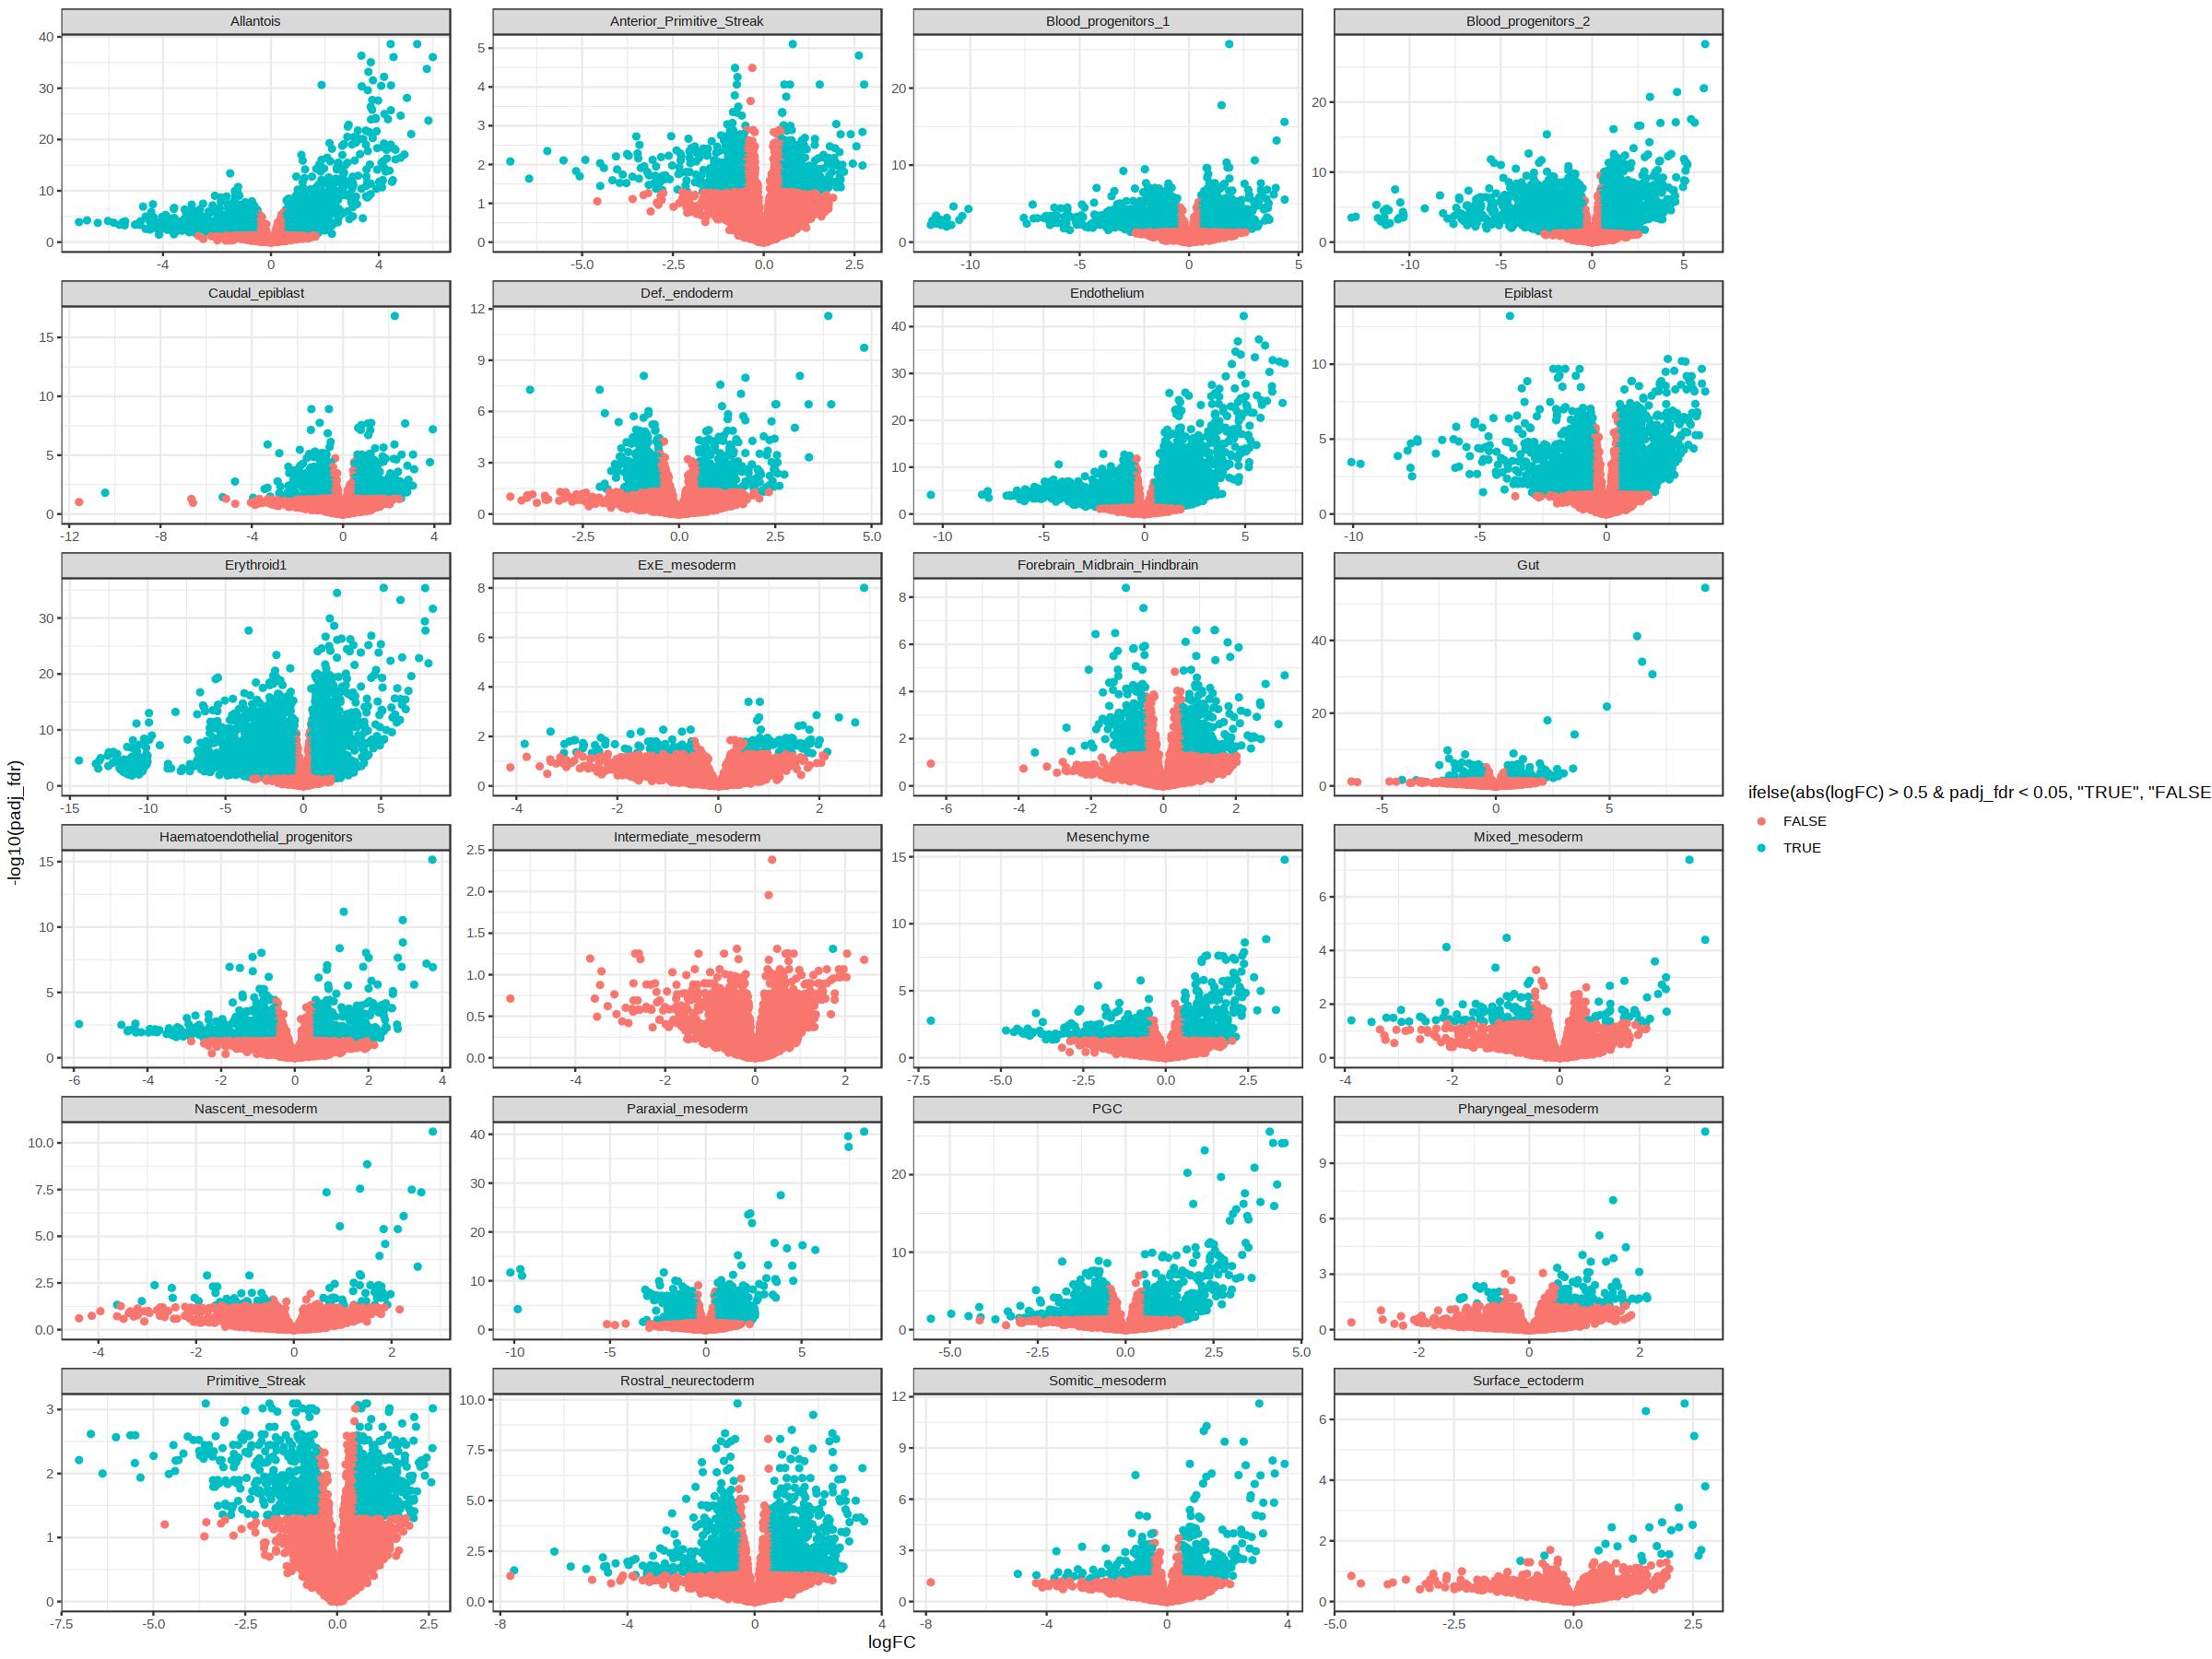

In [78]:
options(repr.plot.width=20, repr.plot.height=15) 

ggplot(DEGs[!is.na(logFC)], aes(logFC, -log10(padj_fdr), col=ifelse(abs(logFC)>0.5 & padj_fdr<0.05, 'TRUE', 'FALSE'))) + 
    geom_point() + 
    facet_wrap(~celltype, ncol = 4, scales='free') + 
    #scale_colour_discrete(values=c('red', 'black')) + 
    theme_bw() 

# single-cell instead of pseudobulk

In [89]:
args$sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')


In [94]:
meta = fread(file.path(io$basedir, 'results/rna/mapping/sample_metadata_after_mapping.txt.gz'))

In [96]:
meta = meta[pass_rnaQC == TRUE & doublet_call == FALSE]

In [114]:
sce = load_SingleCellExperiment(args$sce, cells=meta$cell, normalise = TRUE)


In [151]:
summary(colnames(sce) == meta$cell)

   Mode    TRUE 
logical   38346 

In [119]:
sce = sce[rowMeans(logcounts(sce))>0,]

In [120]:
sce

class: SingleCellExperiment 
dim: 28550 38346 
metadata(0):
assays(2): counts logcounts
rownames(28550): Xkr4 Gm1992 ... CAAA01147332.1 AC149090.1
rowData names(0):
colnames(38346): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(11): barcode sample ... pass_rnaQC sizeFactor
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [141]:
DEGs = lapply(args$celltypes, function(ct, min_cells = 25, min.expr=0.5){

        args$groupA = ct
        args$groupB = setdiff(args$celltypes,ct)
    if (nrow(meta[celltype == args$groupA]) < min_cells | nrow(meta[celltype %in% args$groupB]) < min_cells) {
      message(paste0(ct, ' skipped'))
      out <- data.table(gene=NA, logFC=NA, padj_fdr=NA, mean_groupA=NA, mean_groupB=NA)
      #fwrite(out, args$outfile, sep="\t", na="NA", quote=F)
    } else {
        message(ct)
        #########################################
        ## Calculate average expression levels ##
        #########################################

        expr.dt <- data.table(
          gene = rownames(sce),
          mean_groupA = rowMeans(logcounts(sce[,meta$celltype==args$groupA])) %>% round(2),
          mean_groupB = rowMeans(logcounts(sce[,meta$celltype%in%args$groupB])) %>% round(2)
        )

        #######################
        ## Feature selection ##
        #######################

        # 2**4 = 16, at least an average of 8 counts per milion for each group

        genes.to.use <- expr.dt[mean_groupA>=min.expr | mean_groupB>=min.expr,gene]

        ################################################
        ## Differential expression testing with edgeR ##
        ################################################

        # Convert SCE to DGEList
        sce_edger <- scran::convertTo(sce[genes.to.use,], type="edgeR")
        sce_edger$design = ifelse(meta$celltype==ct, 'group', 'bg')

    
        # Define design matrix (with intercept)
        design <- model.matrix(~sce_edger$design)

        # Estimate dispersions
        sce_edger  <- estimateDisp(sce_edger,design)

        # Fit GLM
        fit <- glmQLFit(sce_edger,design)

        # Likelihood ratio test
        lrt <- glmQLFTest(fit)

        # Construct output data.frame
        out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
          setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
          .[,c("logCPM","LR","p.value"):=NULL] %>%
          .[,c("padj_fdr","logFC"):=list(signif(padj_fdr,digits=3), round(logFC,3))] %>%
          merge(expr.dt, by="gene", all.y=TRUE) %>%
          setorder(padj_fdr, na.last=T)
    }
    out = out %>% .[,celltype:=ct]
    return(out)
}) %>% rbindlist(.)

Epiblast



ERROR: Error in glmFit.default(sely, design, offset = seloffset, dispersion = 0.05, : nrow(design) disagrees with ncol(y)


In [142]:
ct = 'Epiblast'
min.expr = 0.5

In [143]:
 message(ct)
        #########################################
        ## Calculate average expression levels ##
        #########################################

        expr.dt <- data.table(
          gene = rownames(sce),
          mean_groupA = rowMeans(logcounts(sce[,meta$celltype==args$groupA])) %>% round(2),
          mean_groupB = rowMeans(logcounts(sce[,meta$celltype%in%args$groupB])) %>% round(2)
        )

        #######################
        ## Feature selection ##
        #######################

        # 2**4 = 16, at least an average of 8 counts per milion for each group

        genes.to.use <- expr.dt[mean_groupA>=min.expr | mean_groupB>=min.expr,gene]

Epiblast



In [152]:
        ################################################
        ## Differential expression testing with edgeR ##
        ################################################

        # Convert SCE to DGEList
        sce_edger <- scran::convertTo(sce[genes.to.use,], type="edgeR")
        sce_edger$design = ifelse(meta$celltype==ct, 'group', 'bg')
    
        # Define design matrix (with intercept)
        design <- model.matrix(~sce_edger$design)


In [153]:
sce_edger$count

[1] "group" "bg"    "group" "bg"    "group" "bg"    "bg"    "bg"    "bg"   
   [10] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "group" "bg"   
   [19] "group" "bg"    "group" "bg"    "bg"    "bg"    "bg"    "group" "bg"   
   [28] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
   [37] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
   [46] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
   [55] "group" "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
   [64] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
   [73] "group" "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
   [82] "bg"    "bg"    "bg"    "bg"    "group" "bg"    "bg"    "bg"    "group"
   [91] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [100] "bg"    "bg"    "bg"    "bg"    "bg"    "group" "bg"    "bg"    "bg"   
  [109] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [118] "bg"    "group" "bg"    "bg"    "group" "bg"    "bg"    "group" "bg"   
  [127] "bg"    "bg"    "group" "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [136] "bg"    "bg"    "bg"    "group" "bg"    "bg"    "bg"    "bg"    "bg"   
  [145] "group" "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "group"
  [154] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [163] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [172] "bg"    "bg"    "bg"    "group" "bg"    "bg"    "bg"    "bg"    "bg"   
  [181] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [190] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "group" "bg"   
  [199] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "group" "bg"    "bg"   
  [208] "bg"    "bg"    "bg"    "bg"    "group" "bg"    "bg"    "bg"    "bg"   
  [217] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [226] "bg"    "group" "group" "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [235] "bg"    "group" "bg"    "bg"    "bg"    "group" "bg"    "bg"    "bg"   
  [244] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [253] "bg"    "bg"    "group" "group" "bg"    "bg"    "bg"    "bg"    "bg"   
  [262] "group" "bg"    "bg"    "group" "bg"    "bg"    "group" "bg"    "bg"   
  [271] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "group" "bg"    "bg"   
  [280] "bg"    "bg"    "bg"    "group" "bg"    "bg"    "bg"    "bg"    "group"
  [289] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [298] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "group" "bg"    "bg"   
  [307] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [316] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [325] "bg"    "bg"    "bg"    "bg"    "bg"    "group" "bg"    "bg"    "bg"   
  [334] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [343] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [352] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [361] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "group" "bg"    "bg"   
  [370] "bg"    "bg"    "bg"    "bg"    "bg"    "group" "bg"    "bg"    "bg"   
  [379] "bg"    "group" "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [388] "group" "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [397] "group" "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [406] "group" "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [415] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [424] "bg"    "bg"    "bg"    "bg"    "group" "bg"    "bg"    "bg"    "bg"   
  [433] "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"    "bg"   
  [442] "bg"    "bg"    "bg"    "bg"    "group" "bg"    "bg"    "bg"    "bg"   
  [4

In [157]:

        # Estimate dispersions
        sce_edger  <- estimateDisp(sce_edger,design)


In [ ]:

        # Fit GLM
        fit <- glmQLFit(sce_edger,design)


In [ ]:

        # Likelihood ratio test
        lrt <- glmQLFTest(fit)

        # Construct output data.frame
        out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
          setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
          .[,c("logCPM","LR","p.value"):=NULL] %>%
          .[,c("padj_fdr","logFC"):=list(signif(padj_fdr,digits=3), round(logFC,3))] %>%
          merge(expr.dt, by="gene", all.y=TRUE) %>%
          setorder(padj_fdr, na.last=T)

In [156]:
head(fit)

An object of class "DGEGLM"
$coefficients
        (Intercept) sce_edger$designgroup
Xkr4      -9.108015            0.69535632
Mrpl15    -9.316894            0.26396866
Lypla1    -9.975541            0.34491374
Tcea1     -8.803952            0.02272698
Rgs20    -10.363721           -1.05761298
Atp6v1h   -8.904330           -0.20156137

$fitted.values
        Allantois_rep1 Allantois_rep2 Allantois_rep3 Allantois_rep4
Xkr4         1817.6224      1793.1081      1807.7794      1820.3260
Mrpl15       1474.9339      1455.0414      1466.9466      1477.1277
Lypla1        763.1895       752.8964       759.0566       764.3247
Tcea1        2463.6517      2430.4244      2450.3103      2467.3162
Rgs20         517.5627       510.5823       514.7599       518.3325
Atp6v1h      2228.3323      2198.2788      2216.2652      2231.6468
        Allantois_rep5 Anterior_Primitive_Streak_rep1
Xkr4         1780.5105                      216.67563
Mrpl15       1444.8189                      175.82432
Lypla1    